# Capstone Project: Analisis Dataset Lowongan Kerja

Notebook ini disusun sebagai bagian dari proyek capstone untuk menganalisis dataset lowongan kerja. Analisis dilakukan melalui tahapan data collection, assessing data, data cleaning, manipulasi data, feature processing, exploratory data analysis (EDA), explanatory analysis, serta pemeriksaan akhir dataset.

Dataset yang digunakan berisi informasi lowongan kerja seperti job title, tipe pekerjaan, salary, dan skill. Pada proyek ini, beberapa kolom diproses ulang agar dataset menjadi lebih bersih, konsisten, dan siap digunakan untuk analisis lanjutan.

## Tujuan Proyek

Tujuan dari analisis ini adalah:

1. Memahami struktur dan karakteristik dataset lowongan kerja.
2. Membersihkan dan mempersiapkan data agar siap dianalisis.
3. Menstandarkan kolom utama seperti job title, job type, salary, dan job skill.
4. Melakukan manipulasi data pada kolom job type dan salary berdasarkan job title.
5. Menghasilkan estimasi gaji bulanan dari rentang salary tahunan.
6. Mengidentifikasi pola distribusi job title, job type, skill, dan estimasi gaji.
7. Menemukan insight yang dapat digunakan sebagai dasar feature engineering atau pengembangan sistem berbasis data lowongan kerja.

## Alur Analisis

Tahapan yang dilakukan dalam notebook ini meliputi:

- Import Library
- Load Dataset
- Data Collection dan Pemeriksaan Awal
- Assessing Data
- Standarisasi Struktur Kolom
- Pemilihan Kolom Penting
- Data Cleaning Awal
- Reset Job Type dan Salary
- Manipulasi Job Type
- Manipulasi Job Skill
- Manipulasi Salary
- Konversi Salary Menjadi Gaji Per Bulan
- Feature Processing
- Dataset Final
- Exploratory Data Analysis
- Explanatory Data Analysis
- Pemeriksaan Akhir Dataset
- Simpan Dataset

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

from collections import Counter
from itertools import combinations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset

In [ ]:
path = "/content/drive/MyDrive/data1/datasetfull (3).csv"

In [ ]:
df = pd.read_csv(path, low_memory=False)

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (62268, 11)


,job_title,job_description,company,location,work_type,salary,clean_text,job_skills,job_skill_count,category,text_length
0,NaN,While many industries were hurt by the last fe...,NaN,"Chico, CA",FULL_TIME,NaN,while many industries were hurt by the last fe...,['excel'],1,other,298
1,Procurement Executive (Contract),Position Purpose\nManage aspects of procuremen...,Coca-Cola Bottlers (Malaysia) Sdn Bhd,Negeri Sembilan,NaN,NaN,procurement executive contract position purpos...,[],0,other,298
2,Account Executive/ Assistant,We are looking for a Account Executive/ Assist...,Acoustic & Lighting System Sdn Bhd,Petaling,NaN,"RM 2,800 – RM 3,200 per month",account executive assistant we are looking for...,[],0,other,147
3,"Data Analyst - Asset Management, SPX Express",Performs detailed data analysis on existing sp...,Shopee Mobile Malaysia Sdn Bhd,Klang District,NaN,NaN,data analyst asset management spx express perf...,['data analysis'],1,data,144
4,Service Engineer,"You are important for troubleshooting, install...",Sun Medical Systems Sdn Bhd,Petaling,NaN,"RM 3,000 – RM 3,500 per month",service engineer you are important for trouble...,['react'],1,software,246


## Data Collection dan Pemeriksaan Awal

In [ ]:
print("Shape dataset:", df.shape)

Shape dataset: (62268, 11)


In [ ]:
print("Kolom dataset:")
print(df.columns)

Kolom dataset:
Index(['job_title', 'job_description', 'company', 'location', 'work_type',
       'salary', 'clean_text', 'job_skills', 'job_skill_count', 'category',
       'text_length'],
      dtype='object')


In [ ]:
df.head()

,job_title,job_description,company,location,work_type,salary,clean_text,job_skills,job_skill_count,category,text_length
0,NaN,While many industries were hurt by the last fe...,NaN,"Chico, CA",FULL_TIME,NaN,while many industries were hurt by the last fe...,['excel'],1,other,298
1,Procurement Executive (Contract),Position Purpose\nManage aspects of procuremen...,Coca-Cola Bottlers (Malaysia) Sdn Bhd,Negeri Sembilan,NaN,NaN,procurement executive contract position purpos...,[],0,other,298
2,Account Executive/ Assistant,We are looking for a Account Executive/ Assist...,Acoustic & Lighting System Sdn Bhd,Petaling,NaN,"RM 2,800 – RM 3,200 per month",account executive assistant we are looking for...,[],0,other,147
3,"Data Analyst - Asset Management, SPX Express",Performs detailed data analysis on existing sp...,Shopee Mobile Malaysia Sdn Bhd,Klang District,NaN,NaN,data analyst asset management spx express perf...,['data analysis'],1,data,144
4,Service Engineer,"You are important for troubleshooting, install...",Sun Medical Systems Sdn Bhd,Petaling,NaN,"RM 3,000 – RM 3,500 per month",service engineer you are important for trouble...,['react'],1,software,246


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62268 entries, 0 to 62267
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        62267 non-null  object
 1   job_description  62268 non-null  object
 2   company          62267 non-null  object
 3   location         62268 non-null  object
 4   work_type        1 non-null      object
 5   salary           28284 non-null  object
 6   clean_text       62268 non-null  object
 7   job_skills       62268 non-null  object
 8   job_skill_count  62268 non-null  int64 
 9   category         62268 non-null  object
 10  text_length      62268 non-null  int64 
dtypes: int64(2), object(9)
memory usage: 5.2+ MB


## Assessing Data

In [ ]:
df.isnull().sum()

,0
job_title,1
job_description,0
company,1
location,0
work_type,62267
salary,33984
clean_text,0
job_skills,0
job_skill_count,0
category,0


In [ ]:
missing = df.isnull().sum().reset_index()
missing.columns = ["column", "missing_count"]
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100

missing.sort_values(by="missing_pct", ascending=False)

,column,missing_count,missing_pct
4,work_type,62267,99.998394
5,salary,33984,54.576990
0,job_title,1,0.001606
2,company,1,0.001606
1,job_description,0,0.000000
3,location,0,0.000000
6,clean_text,0,0.000000
7,job_skills,0,0.000000
8,job_skill_count,0,0.000000
9,category,0,0.000000


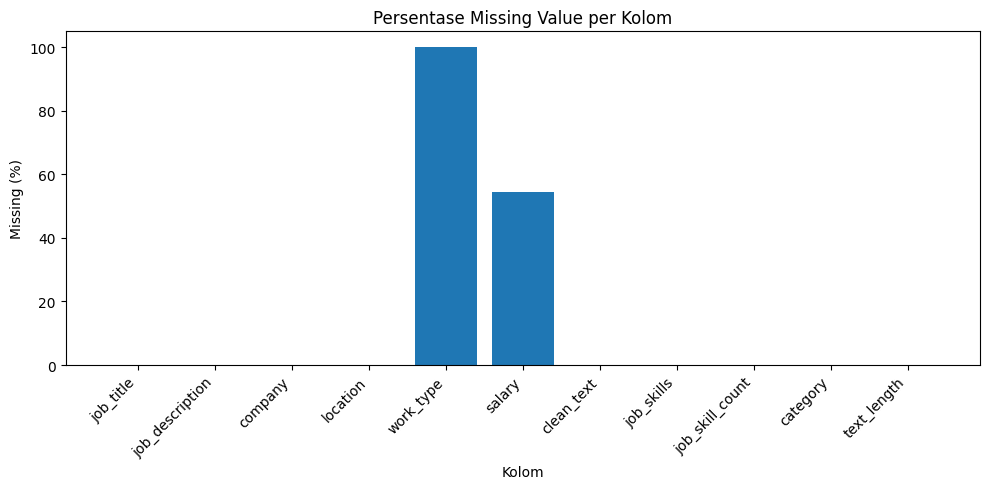

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(missing["column"], missing["missing_pct"])
plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [ ]:
df.nunique().sort_values(ascending=False)

,0
clean_text,62119
job_description,60672
job_title,40404
company,20669
salary,2040
text_length,1493
location,641
job_skills,90
job_skill_count,7
category,3


In [ ]:
df.nunique().sort_values(ascending=False)

,0
clean_text,62119
job_description,60672
job_title,40404
company,20669
salary,2040
text_length,1493
location,641
job_skills,90
job_skill_count,7
category,3


In [ ]:
df.describe()

,job_skill_count,text_length
count,62268.000000,62268.000000
mean,0.584361,319.116448
std,0.722123,228.900951
min,0.000000,3.000000
25%,0.000000,167.000000
50%,0.000000,254.000000
75%,1.000000,401.000000
max,6.000000,2499.000000


## Standarisasi Struktur Kolom

In [ ]:
df.columns

Index(['job_title', 'job_description', 'company', 'location', 'work_type',
       'salary', 'clean_text', 'job_skills', 'job_skill_count', 'category',
       'text_length'],
      dtype='object')

In [ ]:
df = df.rename(columns={
    "job_title": "Job_Title",
    "work_type": "Job_Type",
    "salary": "Salary",
    "job_skills": "Job_Skill"
})

df.columns

Index(['Job_Title', 'job_description', 'company', 'location', 'Job_Type',
       'Salary', 'clean_text', 'Job_Skill', 'job_skill_count', 'category',
       'text_length'],
      dtype='object')

## Pemilihan Kolom Penting

In [ ]:
selected_cols = [
    "Job_Title",
    "Job_Type",
    "Salary",
    "Job_Skill"
]

df = df[selected_cols].copy()

print("Shape setelah memilih kolom penting:", df.shape)
df.head()

Shape setelah memilih kolom penting: (62268, 4)


,Job_Title,Job_Type,Salary,Job_Skill
0,NaN,FULL_TIME,NaN,['excel']
1,Procurement Executive (Contract),NaN,NaN,[]
2,Account Executive/ Assistant,NaN,"RM 2,800 – RM 3,200 per month",[]
3,"Data Analyst - Asset Management, SPX Express",NaN,NaN,['data analysis']
4,Service Engineer,NaN,"RM 3,000 – RM 3,500 per month",['react']


## Data Cleaning

In [ ]:
df = df.drop_duplicates()

print("Shape setelah menghapus duplikat:", df.shape)

Shape setelah menghapus duplikat: (42389, 9)


In [ ]:
df["Job_Title"] = df["Job_Title"].fillna("unknown").astype(str).str.strip()
df["Job_Skill"] = df["Job_Skill"].fillna("[]").astype(str).str.strip()

df["Job_Title"] = df["Job_Title"].replace(["", "nan", "None", "none", "NaN"], "unknown")
df["Job_Skill"] = df["Job_Skill"].replace(["", "nan", "None", "none", "NaN"], "[]")

df.head()

,Job_Title,Job_Type,Salary,Job_Skill,salary_min_yearly,salary_max_yearly,gaji_min_perbulan,gaji_max_perbulan,Gaji_Perbulan
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY",Communication,45000,90750,3750,7562,"3,750 - 7,562"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,50000,75000,4167,6250,"4,167 - 6,250"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,60000,90000,5000,7500,"5,000 - 7,500"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,70000,105000,5833,8750,"5,833 - 8,750"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,45000,82500,3750,6875,"3,750 - 6,875"


In [ ]:
df = df[df["Job_Title"].str.lower() != "unknown"].copy()

print("Shape setelah menghapus Job_Title unknown:", df.shape)
df.head()

Shape setelah menghapus Job_Title unknown: (42389, 9)


,Job_Title,Job_Type,Salary,Job_Skill,salary_min_yearly,salary_max_yearly,gaji_min_perbulan,gaji_max_perbulan,Gaji_Perbulan
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY",Communication,45000,90750,3750,7562,"3,750 - 7,562"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,50000,75000,4167,6250,"4,167 - 6,250"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,60000,90000,5000,7500,"5,000 - 7,500"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,70000,105000,5833,8750,"5,833 - 8,750"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,45000,82500,3750,6875,"3,750 - 6,875"


## Reset Job Type dan Salary

In [ ]:
def assign_job_type(job_title):
    title = str(job_title).lower()

    if any(word in title for word in ["intern", "internship", "trainee"]):
        return "Internship"

    elif any(word in title for word in ["part time", "part-time", "freelance"]):
        return "Part-time"

    elif any(word in title for word in ["contract", "temporary", "project"]):
        return "Contract"

    else:
        return "Full-time"

In [ ]:
df["Job_Type"] = df["Job_Title"].apply(assign_job_type)

df[["Job_Title", "Job_Type"]].head(20)

,Job_Title,Job_Type
1,procurement executive (contract),Contract
2,account executive/ assistant,Full-time
3,"data analyst - asset management, spx express",Full-time
4,service engineer,Full-time
5,purchasing executive,Full-time
6,accounts executive,Full-time
7,accounts executive,Full-time
9,accounts assistant (ap),Full-time
10,admin assistant,Full-time
11,clerical assistant (educational centre),Full-time


In [ ]:
df["Job_Type"].value_counts()

,count
Job_Type,
Full-time,37932
Internship,2220
Contract,2050
Part-time,187


## Manipulasi Job Skill

In [ ]:
def clean_job_skill(skill):
    skill = str(skill).lower().strip()

    if skill in ["", "[]", "nan", "none"]:
        return "Communication"

    skill = skill.replace("[", "")
    skill = skill.replace("]", "")
    skill = skill.replace("'", "")
    skill = skill.replace('"', "")

    skill_map = {
        "excel": "Excel",
        "sql": "SQL",
        "python": "Python",
        "java": "Java",
        "react": "React",
        "data analysis": "Data Analysis",
        "machine learning": "Machine Learning"
    }

    skills = []

    for item in skill.split(","):
        item = item.strip()
        if item in skill_map:
            skills.append(skill_map[item])

    if len(skills) == 0:
        return "Communication"

    return ", ".join(skills)

In [ ]:
df["Job_Skill"] = df["Job_Skill"].apply(clean_job_skill)

df[["Job_Title", "Job_Skill"]].head(20)

,Job_Title,Job_Skill
1,procurement executive (contract),Communication
2,account executive/ assistant,Communication
3,"data analyst - asset management, spx express",Data Analysis
4,service engineer,React
5,purchasing executive,Communication
6,accounts executive,Excel
7,accounts executive,Communication
9,accounts assistant (ap),Communication
10,admin assistant,Excel
11,clerical assistant (educational centre),Communication


In [ ]:
df["Job_Type"].value_counts()

,count
Job_Type,
Full-time,37932
Internship,2220
Contract,2050
Part-time,187


## Manipulasi Salary

In [ ]:
def get_yearly_salary_range(job_title):
    title = str(job_title).lower()

    if any(word in title for word in ["data", "analyst", "scientist", "machine learning", "ai"]):
        return 60000, 90000

    elif any(word in title for word in ["software", "developer", "programmer", "engineer", "it", "technical", "system"]):
        return 70000, 105000

    elif any(word in title for word in ["account", "finance", "audit", "tax", "payroll"]):
        return 50000, 75000

    elif any(word in title for word in ["sales", "marketing", "business development", "account executive"]):
        return 50000, 75000

    elif any(word in title for word in ["manager", "lead", "head", "supervisor"]):
        return 75000, 100000

    elif any(word in title for word in ["admin", "assistant", "clerk", "hr", "human resource", "recruitment"]):
        return 30000, 50000

    elif any(word in title for word in ["designer", "creative", "content", "graphic", "ui", "ux"]):
        return 45000, 70000

    elif any(word in title for word in ["intern", "internship", "trainee"]):
        return 18000, 24000

    else:
        return 45000, 82500

In [ ]:
def adjust_salary_by_job_type(min_salary, max_salary, job_type):
    job_type = str(job_type).lower()

    if job_type == "contract":
        return int(min_salary * 1.0), int(max_salary * 1.1)

    elif job_type == "part-time":
        return int(min_salary * 0.5), int(max_salary * 0.6)

    elif job_type == "internship":
        return 18000, 24000

    else:
        return min_salary, max_salary

In [ ]:
def assign_salary(row):
    min_salary, max_salary = get_yearly_salary_range(row["Job_Title"])

    min_salary, max_salary = adjust_salary_by_job_type(
        min_salary,
        max_salary,
        row["Job_Type"]
    )

    return f"USD {min_salary:,} - {max_salary:,} / YEARLY"

In [ ]:
df["Salary"] = df.apply(assign_salary, axis=1)

df[["Job_Title", "Job_Type", "Salary"]].head(25)

,Job_Title,Job_Type,Salary
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY"
6,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY"
7,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY"
9,accounts assistant (ap),Full-time,"USD 50,000 - 75,000 / YEARLY"
10,admin assistant,Full-time,"USD 30,000 - 50,000 / YEARLY"
11,clerical assistant (educational centre),Full-time,"USD 30,000 - 50,000 / YEARLY"


##  Konversi Salary Menjadi Gaji Per Bulan

In [ ]:
def extract_salary_range(salary):
    salary = str(salary)

    numbers = re.findall(r"\d[\d,]*", salary)
    numbers = [int(num.replace(",", "")) for num in numbers]

    if len(numbers) >= 2:
        return numbers[0], numbers[1]
    elif len(numbers) == 1:
        return numbers[0], numbers[0]
    else:
        return np.nan, np.nan

In [ ]:
df[["salary_min_yearly", "salary_max_yearly"]] = df["Salary"].apply(
    lambda x: pd.Series(extract_salary_range(x))
)

df[["Salary", "salary_min_yearly", "salary_max_yearly"]].head()

,Salary,salary_min_yearly,salary_max_yearly
1,"USD 45,000 - 90,750 / YEARLY",45000,90750
2,"USD 50,000 - 75,000 / YEARLY",50000,75000
3,"USD 60,000 - 90,000 / YEARLY",60000,90000
4,"USD 70,000 - 105,000 / YEARLY",70000,105000
5,"USD 45,000 - 82,500 / YEARLY",45000,82500


In [ ]:
df["gaji_min_perbulan"] = (df["salary_min_yearly"] / 12).round(0).astype("Int64")
df["gaji_max_perbulan"] = (df["salary_max_yearly"] / 12).round(0).astype("Int64")

df["Gaji_Perbulan"] = (
    df["gaji_min_perbulan"].apply(lambda x: f"{x:,}") + " - " +
    df["gaji_max_perbulan"].apply(lambda x: f"{x:,}")
)

df[["Salary", "Gaji_Perbulan"]].head(20)

,Salary,Gaji_Perbulan
1,"USD 45,000 - 90,750 / YEARLY","3,750 - 7,562"
2,"USD 50,000 - 75,000 / YEARLY","4,167 - 6,250"
3,"USD 60,000 - 90,000 / YEARLY","5,000 - 7,500"
4,"USD 70,000 - 105,000 / YEARLY","5,833 - 8,750"
5,"USD 45,000 - 82,500 / YEARLY","3,750 - 6,875"
6,"USD 50,000 - 75,000 / YEARLY","4,167 - 6,250"
7,"USD 50,000 - 75,000 / YEARLY","4,167 - 6,250"
9,"USD 50,000 - 75,000 / YEARLY","4,167 - 6,250"
10,"USD 30,000 - 50,000 / YEARLY","2,500 - 4,167"
11,"USD 30,000 - 50,000 / YEARLY","2,500 - 4,167"


## Data Processing

In [ ]:
def split_skills(skill):
    skill = str(skill).strip()

    if skill == "" or skill.lower() in ["nan", "none"]:
        return []

    return [s.strip() for s in skill.split(",") if s.strip() != ""]

In [ ]:
def split_skills(skill):
    skill = str(skill).strip()

    if skill == "" or skill.lower() in ["nan", "none"]:
        return []

    return [s.strip() for s in skill.split(",") if s.strip() != ""]

In [ ]:
def extract_monthly_salary_avg(gaji):
    numbers = re.findall(r"\d[\d,]*", str(gaji))
    numbers = [int(num.replace(",", "")) for num in numbers]

    if len(numbers) >= 2:
        return (numbers[0] + numbers[1]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return np.nan

In [ ]:
def extract_monthly_salary_avg(gaji):
    numbers = re.findall(r"\d[\d,]*", str(gaji))
    numbers = [int(num.replace(",", "")) for num in numbers]

    if len(numbers) >= 2:
        return (numbers[0] + numbers[1]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return np.nan

## Dataset Final

In [ ]:
df_final = df[[
    "Job_Title",
    "Job_Type",
    "Salary",
    "Job_Skill",
    "Gaji_Perbulan"
]].copy()

print("Shape dataset final:", df_final.shape)
df_final.head(25)

Shape dataset final: (42389, 5)


,Job_Title,Job_Type,Salary,Job_Skill,Gaji_Perbulan
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY",Communication,"3,750 - 7,562"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,"5,000 - 7,500"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,"5,833 - 8,750"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875"
6,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Excel,"4,167 - 6,250"
7,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
9,accounts assistant (ap),Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
10,admin assistant,Full-time,"USD 30,000 - 50,000 / YEARLY",Excel,"2,500 - 4,167"
11,clerical assistant (educational centre),Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167"


In [ ]:
df_final = df[[
    "Job_Title",
    "Job_Type",
    "Salary",
    "Job_Skill",
    "Gaji_Perbulan"
]].copy()

print("Shape dataset final:", df_final.shape)
df_final.head(25)

Shape dataset final: (42389, 5)


,Job_Title,Job_Type,Salary,Job_Skill,Gaji_Perbulan
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY",Communication,"3,750 - 7,562"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,"5,000 - 7,500"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,"5,833 - 8,750"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875"
6,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Excel,"4,167 - 6,250"
7,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
9,accounts assistant (ap),Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
10,admin assistant,Full-time,"USD 30,000 - 50,000 / YEARLY",Excel,"2,500 - 4,167"
11,clerical assistant (educational centre),Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167"


In [ ]:
print("Jumlah duplikat:", df_final.duplicated().sum())

Jumlah duplikat: 0


In [ ]:
df_final.isnull().sum()

,0
Job_Title,0
Job_Type,0
Salary,0
Job_Skill,0
Gaji_Perbulan,0


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42389 entries, 1 to 62266
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Job_Title      42389 non-null  object
 1   Job_Type       42389 non-null  object
 2   Salary         42389 non-null  object
 3   Job_Skill      42389 non-null  object
 4   Gaji_Perbulan  42389 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [ ]:
df_final.head(25)

,Job_Title,Job_Type,Salary,Job_Skill,Gaji_Perbulan
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY",Communication,"3,750 - 7,562"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,"5,000 - 7,500"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,"5,833 - 8,750"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875"
6,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Excel,"4,167 - 6,250"
7,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
9,accounts assistant (ap),Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
10,admin assistant,Full-time,"USD 30,000 - 50,000 / YEARLY",Excel,"2,500 - 4,167"
11,clerical assistant (educational centre),Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167"


## Exploratory Data Analysis

### Distribusi Job Title

In [ ]:
job_title_counts = df_final["Job_Title"].value_counts().head(10)

job_title_counts

,count
Job_Title,
software engineer,31
software developer,25
senior software engineer,22
data engineer,17
full stack developer,17
data analyst,16
data scientist,16
business analyst,15
devops engineer,14


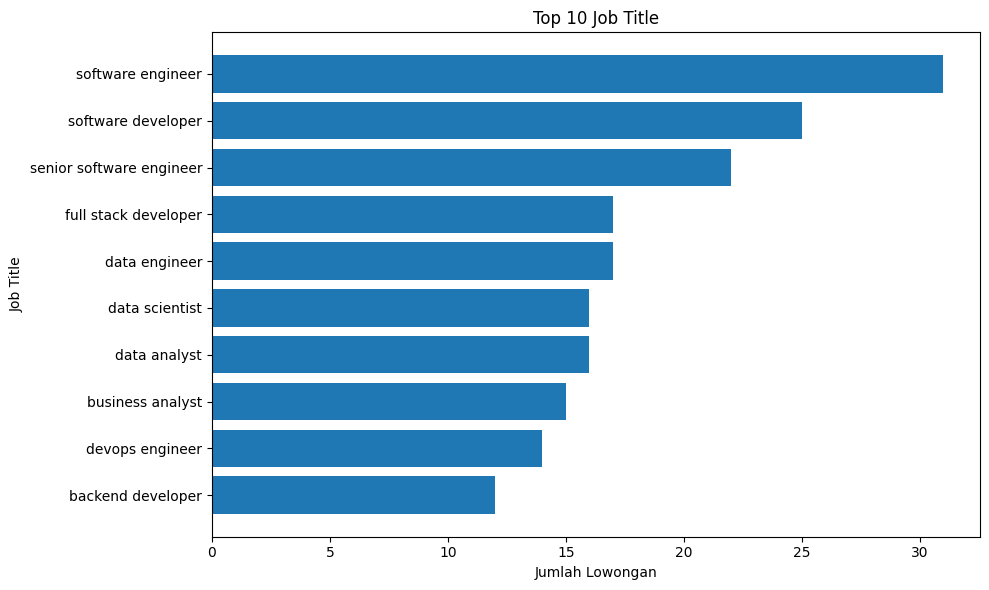

In [ ]:
job_title_counts_plot = job_title_counts.sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(job_title_counts_plot.index, job_title_counts_plot.values)
plt.title("Top 10 Job Title")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

### Distribusi Job Type

In [ ]:
job_type_counts = df_final["Job_Type"].value_counts()

job_type_counts

,count
Job_Type,
Full-time,37932
Internship,2220
Contract,2050
Part-time,187


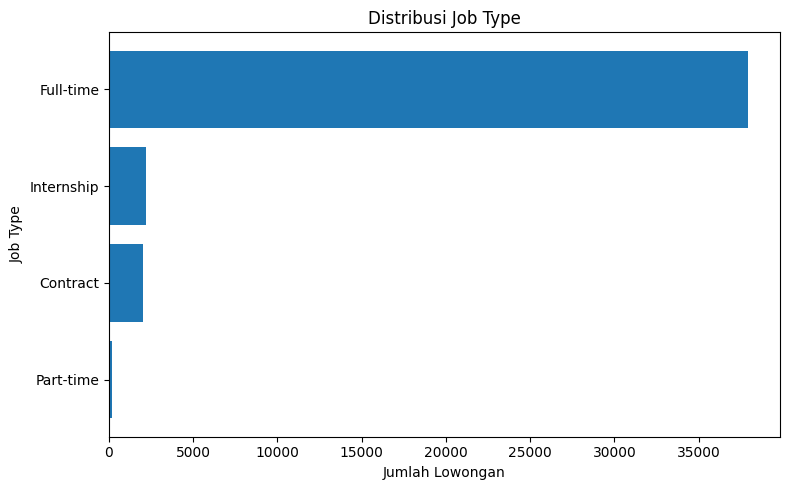

In [ ]:
job_type_counts_plot = job_type_counts.sort_values(ascending=True)

plt.figure(figsize=(8,5))
plt.barh(job_type_counts_plot.index, job_type_counts_plot.values)
plt.title("Distribusi Job Type")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()

### Distribusi Job Skill

In [ ]:
skill_counts = df_final["Job_Skill"].value_counts().head(10)

skill_counts

,count
Job_Skill,
Communication,20827
Excel,16024
"Excel, Data Analysis",791
SQL,688
"SQL, Excel",668
Data Analysis,482
"SQL, Java",256
Java,244
React,181


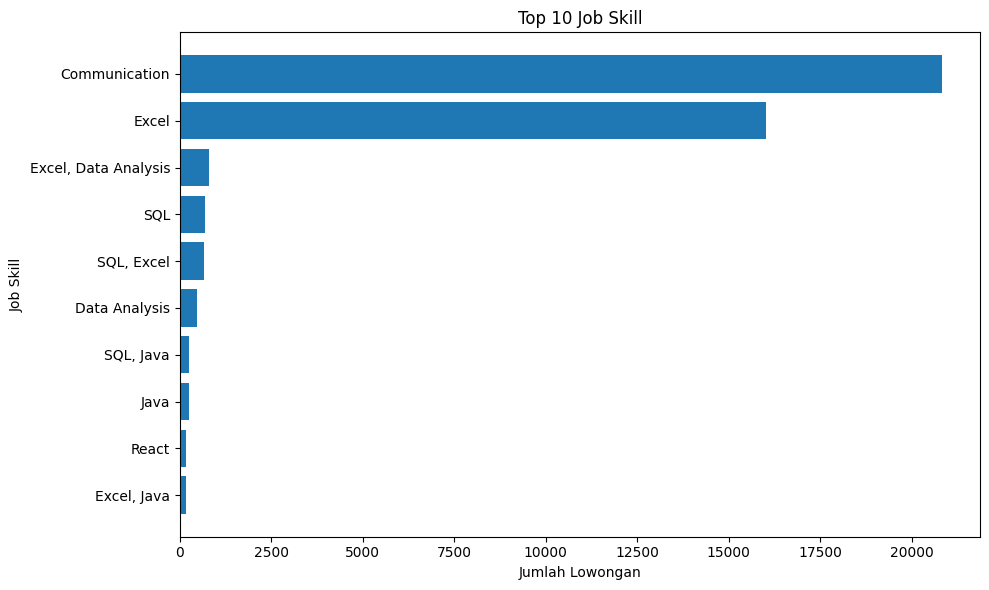

In [ ]:
skill_counts_plot = skill_counts.sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(skill_counts_plot.index, skill_counts_plot.values)
plt.title("Top 10 Job Skill")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Job Skill")
plt.tight_layout()
plt.show()

### Analisis Gaji Per Bulan

In [ ]:
df_final["Rata_Rata_Gaji_Perbulan"] = df_final["Gaji_Perbulan"].apply(extract_monthly_salary_avg)

df_final[["Gaji_Perbulan", "Rata_Rata_Gaji_Perbulan"]].head()

,Gaji_Perbulan,Rata_Rata_Gaji_Perbulan
1,"3,750 - 7,562",5656.0
2,"4,167 - 6,250",5208.5
3,"5,000 - 7,500",6250.0
4,"5,833 - 8,750",7291.5
5,"3,750 - 6,875",5312.5


In [ ]:
df_final["Rata_Rata_Gaji_Perbulan"].describe()

,Rata_Rata_Gaji_Perbulan
count,42389.000000
mean,5737.473201
std,1530.412446
min,1750.000000
25%,5208.500000
50%,5312.500000
75%,7291.500000
max,7729.000000


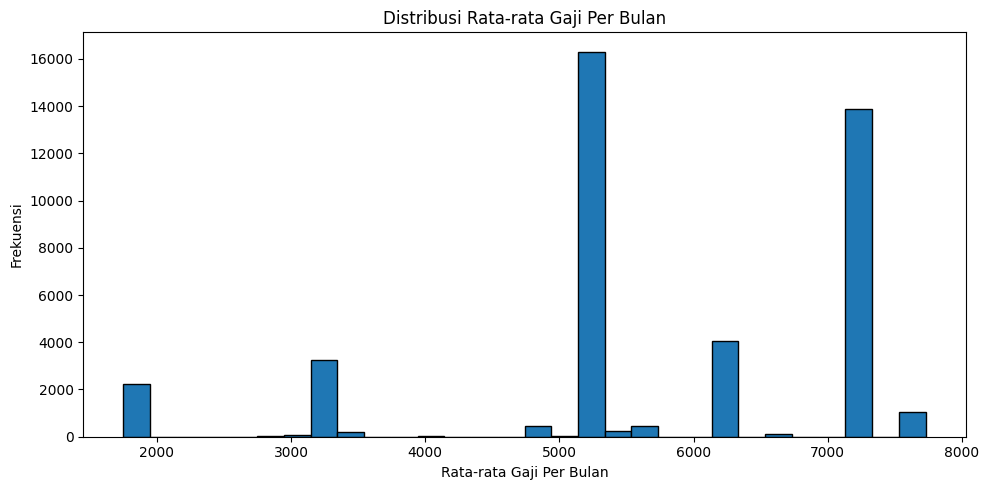

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df_final["Rata_Rata_Gaji_Perbulan"], bins=30, edgecolor="black")
plt.title("Distribusi Rata-rata Gaji Per Bulan")
plt.xlabel("Rata-rata Gaji Per Bulan")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

## Explanatory Data Analysis

Berdasarkan hasil exploratory data analysis, dapat disimpulkan bahwa distribusi lowongan kerja tidak merata pada seluruh job title. Beberapa posisi muncul lebih dominan dibandingkan posisi lainnya, yang menunjukkan adanya konsentrasi kebutuhan tenaga kerja pada posisi tertentu.

Dari sisi job type, hasil manipulasi data menunjukkan bahwa sebagian besar lowongan dikategorikan sebagai full-time. Beberapa lowongan dikategorikan sebagai contract, part-time, atau internship berdasarkan kata kunci yang terdapat pada job title.

Dari sisi job skill, beberapa skill seperti Communication, Excel, SQL, Python, React, Data Analysis, dan Machine Learning muncul sebagai skill utama yang digunakan dalam dataset final. Skill ini diperoleh dari dataset asli dan dirapikan agar lebih mudah dianalisis.

Dari sisi salary, nilai salary pada dataset final merupakan hasil imputasi berdasarkan job title dan job type. Salary dibuat dalam bentuk rentang tahunan, kemudian dikonversi menjadi estimasi gaji per bulan. Hasil analisis gaji menunjukkan bahwa job title tertentu memiliki estimasi gaji yang lebih tinggi dibandingkan job title lainnya.

Secara keseluruhan, dataset final telah memiliki struktur yang lebih bersih dan konsisten, sehingga dapat digunakan untuk analisis lanjutan, feature engineering, maupun pengembangan model berbasis data lowongan kerja.

## Simpan Dataset Final

In [ ]:
df_final_save = df_final[[
    "Job_Title",
    "Job_Type",
    "Salary",
    "Job_Skill",
    "Gaji_Perbulan"
]].copy()

output_path = "/content/drive/MyDrive/data1/job_dataset_final_cleaned.csv"

df_final_save.to_csv(output_path, index=False)

print("Dataset final berhasil disimpan ke:", output_path)
print("Shape dataset final:", df_final_save.shape)
df_final_save.head(25)

Dataset final berhasil disimpan ke: /content/drive/MyDrive/data1/job_dataset_final_cleaned.csv
Shape dataset final: (42389, 5)


,Job_Title,Job_Type,Salary,Job_Skill,Gaji_Perbulan
1,procurement executive (contract),Contract,"USD 45,000 - 90,750 / YEARLY",Communication,"3,750 - 7,562"
2,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
3,"data analyst - asset management, spx express",Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,"5,000 - 7,500"
4,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,"5,833 - 8,750"
5,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875"
6,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Excel,"4,167 - 6,250"
7,accounts executive,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
9,accounts assistant (ap),Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250"
10,admin assistant,Full-time,"USD 30,000 - 50,000 / YEARLY",Excel,"2,500 - 4,167"
11,clerical assistant (educational centre),Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167"
